In [80]:
# EDA library
import pandas as pd
import matplotlib.pyplot as plt

# NLP libraries
import nltk
nltk.download('punkt_tab')
import re
import html
from nltk.corpus import stopwords
from numpy import negative
import numpy as np

# Machine learning libraries
import wandb
import glob, os, json, zipfile
import torch
from transformers import BertForSequenceClassification, Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, get_dataset_config_info, load_dataset_builder

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
device

device(type='cuda')

In [4]:
# Load dataset
dataset = load_dataset('imdb')
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [5]:
label_names = dataset["train"].features["label"].names

# Exploratory data analysis with Pandas
def to_df(split: str) -> pd.DataFrame:
    df = dataset[split].to_pandas()
    df["label_name"] = df["label"].map(lambda i: label_names[i])
    df["n_chars"] = df["text"].str.len()
    df["n_words"] = df["text"].str.split().map(len)
    return df

train_df = to_df("train")
test_df  = to_df("test")

In [6]:
train_df

,text,label,label_name,n_chars,n_words
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,neg,1640,288
1,"""I Am Curious: Yellow"" is a risible and preten...",0,neg,1294,214
2,If only to avoid making this type of film in t...,0,neg,528,93
3,This film was probably inspired by Godard's Ma...,0,neg,706,118
4,"Oh, brother...after hearing about this ridicul...",0,neg,1814,311
...,...,...,...,...,...
24995,A hit at the time but now better categorised a...,1,pos,637,108
24996,I love this movie like no other. Another time ...,1,pos,1091,183
24997,This film and it's sequel Barry Mckenzie holds...,1,pos,740,134
24998,'The Adventures Of Barry McKenzie' started lif...,1,pos,4066,717


In [7]:
train_df["label_name"].value_counts()

label_name
neg    12500
pos    12500
Name: count, dtype: int64

In [8]:
negative_df = train_df[train_df["label_name"] == "neg"][["n_chars", "n_words"]]
negative_df.describe().round(2)

,n_chars,n_words
count,12500.00,12500.00
mean,1302.98,230.87
std,957.07,166.66
min,52.00,10.00
25%,709.00,128.00
50%,976.50,174.00
75%,1568.00,278.00
max,8969.00,1522.00


In [9]:
positive_df = train_df[train_df["label_name"] == "pos"][["n_chars", "n_words"]]
positive_df.describe().round(2)

,n_chars,n_words
count,12500.00,12500.00
mean,1347.16,236.71
std,1046.75,180.49
min,70.00,12.00
25%,695.00,125.00
50%,982.00,174.00
75%,1651.00,291.00
max,13704.00,2470.00


In [10]:
# Remove stopwords from train_df in a new dataframe
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

STOP = set(stopwords.words("english"))

# Optional: keep negations (often useful for sentiment)
STOP_MINUS_NEGATIONS = STOP - {"no", "nor", "not", "never"}

def remove_stopwords(text: str, keep_negations: bool = True) -> str:
    # 1) Decode HTML entities (&quot; etc.)
    text = html.unescape(text)

    # 2) Remove HTML tags (<br />, <p> ...). This kills the "br" token at the source.
    text = re.sub(r"<[^>]+>", " ", text)

    # 3) Normalize apostrophes and lowercase
    text = text.replace("’", "'").lower()

    # 4) Remove URLs (rare but can happen)
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 5) Keep only letters + apostrophes (so "don't" stays as dont or don't)
    # If we wanna KEEP apostrophes, use: r"[^a-z'\s]"
    text = re.sub(r"[^a-z\s]", " ", text)

    # 6) Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # 7) Tokenize
    tokens = nltk.word_tokenize(text)

    # 8) Remove stopwords + short junk tokens
    stopset = STOP_MINUS_NEGATIONS if keep_negations else STOP
    tokens = [
        t for t in tokens
        if t not in stopset
        and len(t) >= 2          # removes single letters such as "s", "t", etc.
    ]

    return " ".join(tokens)

negative_cleaned_df = train_df[train_df["label_name"] == "neg"][["text","n_chars", "n_words"]]
positive_cleaned_df = train_df[train_df["label_name"] == "pos"][["text","n_chars", "n_words"]]

negative_cleaned_df["text"] = negative_cleaned_df["text"].apply(remove_stopwords)
positive_cleaned_df["text"] = positive_cleaned_df["text"].apply(remove_stopwords)

In [11]:
negative_cleaned_df

,text,n_chars,n_words
0,rented curious yellow video store controversy ...,1640,288
1,curious yellow risible pretentious steaming pi...,1294,214
2,avoid making type film future film interesting...,528,93
3,film probably inspired godard masculin minin u...,706,118
4,oh brother hearing ridiculous film umpteen yea...,1814,311
...,...,...,...
12495,enough funny spots not really enough disappoin...,755,144
12496,tainted look kibbutz life film less cultural s...,3241,560
12497,saw movie not released hailed best picture yea...,3126,574
12498,film begins cowhand shagging female calf promi...,701,136


In [12]:
positive_cleaned_df

,text,n_chars,n_words
12500,zentropa much common third man another noir li...,728,121
12501,zentropa original movie seen years like unique...,673,115
12502,lars von trier never backward trying new techn...,2187,387
12503,contains spoilers due describe film techniques...,2544,471
12504,first thing sprang mind watched closing credit...,3225,585
...,...,...,...
24995,hit time better categorised australian cult fi...,637,108
24996,love movie like no another time try explain vi...,1091,183
24997,film sequel barry mckenzie holds two greatest ...,740,134
24998,adventures barry mckenzie started life satiric...,4066,717


In [13]:
# Remove special characters
def remove_special_signs(text):
    # Removes characters that are not letters, numbers, or spaces
    return re.sub(r'[^A-Za-z0-9\s]', '', text)

negative_cleaned_df["text"] = negative_cleaned_df["text"].apply(remove_special_signs)
positive_cleaned_df["text"] = positive_cleaned_df["text"].apply(remove_special_signs)

In [14]:
negative_cleaned_df

,text,n_chars,n_words
0,rented curious yellow video store controversy ...,1640,288
1,curious yellow risible pretentious steaming pi...,1294,214
2,avoid making type film future film interesting...,528,93
3,film probably inspired godard masculin minin u...,706,118
4,oh brother hearing ridiculous film umpteen yea...,1814,311
...,...,...,...
12495,enough funny spots not really enough disappoin...,755,144
12496,tainted look kibbutz life film less cultural s...,3241,560
12497,saw movie not released hailed best picture yea...,3126,574
12498,film begins cowhand shagging female calf promi...,701,136


In [15]:
positive_cleaned_df

,text,n_chars,n_words
12500,zentropa much common third man another noir li...,728,121
12501,zentropa original movie seen years like unique...,673,115
12502,lars von trier never backward trying new techn...,2187,387
12503,contains spoilers due describe film techniques...,2544,471
12504,first thing sprang mind watched closing credit...,3225,585
...,...,...,...
24995,hit time better categorised australian cult fi...,637,108
24996,love movie like no another time try explain vi...,1091,183
24997,film sequel barry mckenzie holds two greatest ...,740,134
24998,adventures barry mckenzie started life satiric...,4066,717


In [16]:
# title="Top Most Used Words in DataFrame (with Cumulative Frequency, nltk)"
def plot_top_words_cumulative_freq(df, text_column="text", top_n=15):
    """
    Plots the top N most frequent words and their cumulative frequencies from a DataFrame text column.

    Args:
        df (pd.DataFrame): DataFrame containing a text column.
        text_column (str): Name of the column containing text data.
        top_n (int): Number of most common words to plot.
        title (str): Plot title.
    """
    all_tokens = []
    for doc in df[text_column].str.lower():
        all_tokens.extend(nltk.word_tokenize(doc))

    freq_dist = nltk.FreqDist(all_tokens)
    total_tokens = len(all_tokens)
    most_common_words = freq_dist.most_common(top_n)
    if not most_common_words or total_tokens == 0:
        print("No words found for plotting.")
        return

    words, counts = zip(*most_common_words)
    percentages = [count / total_tokens * 100 for count in counts]
    cumulative_percentages = pd.Series(percentages).cumsum()

    plt.figure(figsize=(8, 6))
    plt.bar(words, percentages, color="skyblue", label="Frequency (%)")
    plt.plot(words, cumulative_percentages, color='red', marker='o', label="Cumulative Frequency (%)")
    plt.xticks(rotation=90)
    plt.xlabel("Word")
    plt.ylabel("Percentage (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

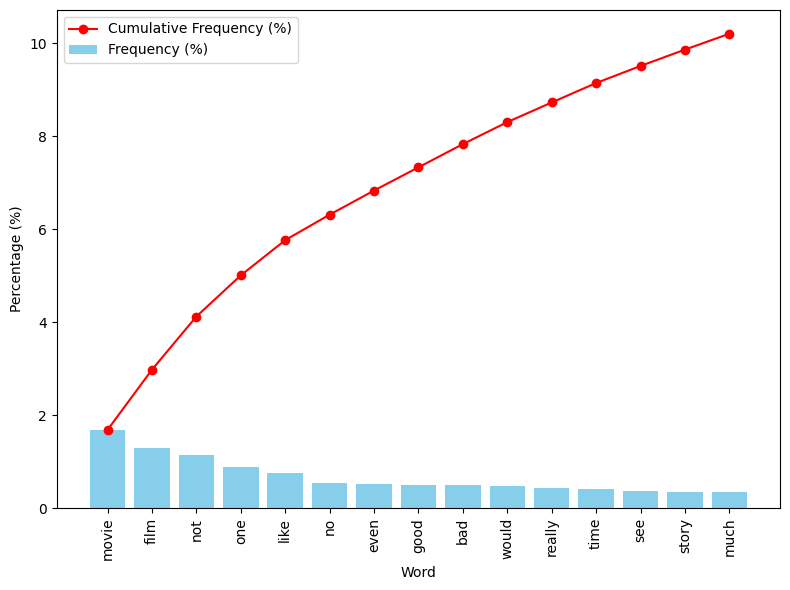

In [17]:
plot_top_words_cumulative_freq(negative_cleaned_df)

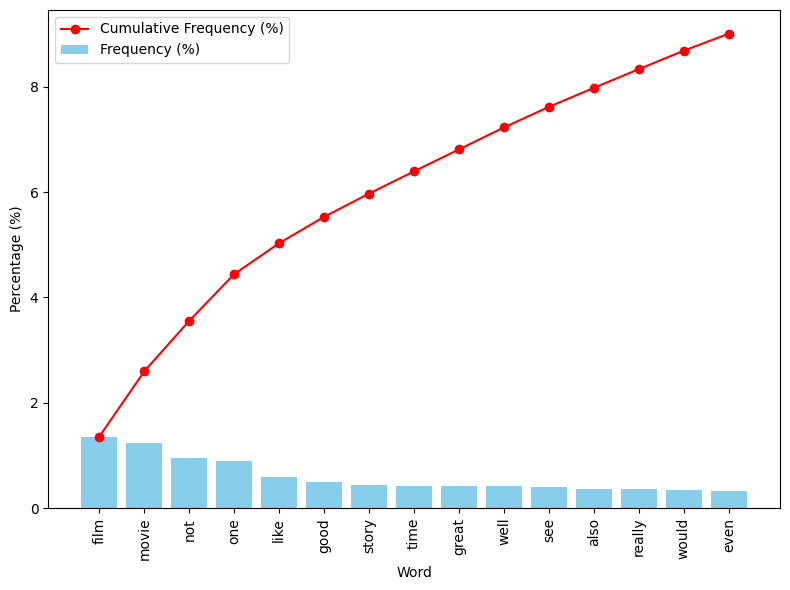

In [18]:
plot_top_words_cumulative_freq(positive_cleaned_df)

In [19]:
# find representative sentences from each class
def find_representative_sentences(
    df,
    text_column="text",
    label_column="label_name",
    top_n=5,
    freq_top_k=50,
    length_tolerance=10,   # +/- words around mean; adjust (e.g., 5, 10, 20)
):
    """
    Finds representative sentences for each class based on word frequency,
    but restricts candidates to reviews with length ~ equal to the class mean.

    Logic:
      1) For each class, compute mean review length (n_words).
      2) Build a set of the top-K most frequent tokens in that class (after cleaning).
      3) Among reviews whose n_words is within +/- length_tolerance of the mean,
         score each review by overlap with the top-K token set.
      4) Return the top_n highest scoring raw reviews for each class.
    """
    representative_sentences = {}
    classes = df[label_column].unique()

    for cls in classes:
        class_df = df[df[label_column] == cls].copy()

        # Mean length for this class
        mean_words = class_df["n_words"].mean()

        # Candidate pool: reviews with length ~ mean
        candidates = class_df[
            (class_df["n_words"] >= mean_words - length_tolerance) &
            (class_df["n_words"] <= mean_words + length_tolerance)
        ].copy()

        # Fallback if tolerance too strict (no candidates)
        if len(candidates) == 0:
            candidates = class_df.copy()

        # Build top-K frequent tokens for this class (after cleaning)
        all_tokens = []
        for doc in class_df[text_column].astype(str).str.lower():
            cleaned_doc = remove_stopwords(doc)  # uses your existing cleaner
            all_tokens.extend(nltk.word_tokenize(cleaned_doc))

        freq_dist = nltk.FreqDist(all_tokens)
        most_common_words = {w for w, _ in freq_dist.most_common(freq_top_k)}

        # Score candidate reviews by overlap with frequent-token set
        sentence_scores = []
        for sentence in candidates[text_column].astype(str):
            cleaned_sentence = remove_stopwords(sentence.lower())
            tokens = set(nltk.word_tokenize(cleaned_sentence))
            score = len(tokens.intersection(most_common_words))
            sentence_scores.append((sentence, score))

        sentence_scores.sort(key=lambda x: x[1], reverse=True)
        representative_sentences[cls] = [s for s, _ in sentence_scores[:top_n]]

    return representative_sentences


representative_sentences = find_representative_sentences(train_df)

In [20]:
type(representative_sentences)

dict

In [21]:
# see the length of representative sentences
for label, sentences in representative_sentences.items():
    print(f"Class: {label}")
    for sentence in sentences:
        print(f"Length: {len(sentence.split())} words - Review: {sentence}")
    print("\n")

Class: neg
Length: 229 words - Review: One of the worst movies I've ever seen. Acting was terrible, both for the kids and the adults. Most to all characters showed no, little or not enough emotion. The lighting was terrible, and there were too many mess ups about the time of the day the film was shot (In the river scene where they just get their boat destroyed, there's 4 shots; The sheriff and Dad in the evening on their boat, Jillian and Molly in the evening swimming, the rest of the kids in the daytime *when it's supposed to in the evening* at the river bank, and the doctor, Beatrice, and Simonton at night but not in the evening getting off their boat.) The best acting in the movie was probably from the sheriff, Cappy (Although, there's a slip of character when the pulse detector *Whatever that thing is when people die, it beeps* shows Cappy has died, he still moves while it can still be heard beeping, and while the nurse extra checks his pulse manually, then it shows the pulse again

## **Task 3.3**

In [22]:
os.getcwd()

'/kaggle/working'

In [23]:
builder = load_dataset_builder("imdb")
print(builder.info)

DatasetInfo(description='', citation='', homepage='', license='', features={'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='imdb', config_name='plain_text', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=33435948, num_examples=25000, shard_lengths=None, dataset_name='imdb'), 'test': SplitInfo(name='test', num_bytes=32653810, num_examples=25000, shard_lengths=None, dataset_name='imdb'), 'unsupervised': SplitInfo(name='unsupervised', num_bytes=67113044, num_examples=50000, shard_lengths=None, dataset_name='imdb')}, download_checksums={'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text/train-00000-of-00001.parquet': {'num_bytes': 20979968, 'checksum': None}, 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text/test-00000-of-00001.parquet': {'num_bytes': 20470363, 'checksum': None}, 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a17

In [24]:
# Load model
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2  # IMDb
)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [25]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [26]:
# Preprocess the data
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding=True)

In [27]:
encoded_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [34]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/results",
    eval_strategy="epoch",     
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=True,
    save_total_limit=2,

    learning_rate=2e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,

    weight_decay=0.01,
    warmup_ratio=0.06,

    fp16=torch.cuda.is_available(),  
    dataloader_pin_memory=torch.cuda.is_available(),

    logging_strategy="steps",
    logging_steps=50,
    report_to="none",               
)

In [35]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset = encoded_dataset["train"],
    eval_dataset = encoded_dataset["test"]
)

### SKIP: skip this step and load the model instead if you don't want unusual long loading time

In [36]:
!pip -q install -U "wandb==0.17.9"

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [37]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

# I have saved my API token with "wandb_api" as Label. 
# If you use some other Label make sure to change the same below. 
wandb_api = user_secrets.get_secret("wandb_api") 

wandb.login(key=wandb_api)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [38]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.287400,0.310258
2,0.245900,0.325833
3,0.077700,0.350469


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=2346, training_loss=0.2116101498494063, metrics={'train_runtime': 5258.7591, 'train_samples_per_second': 14.262, 'train_steps_per_second': 0.446, 'total_flos': 1.9733329152e+16, 'train_loss': 0.2116101498494063, 'epoch': 3.0})

In [39]:
sum(p.requires_grad for p in model.bert.parameters()), sum(1 for _ in model.bert.parameters())

(199, 199)

In [40]:
os.listdir(".")


['wandb', '.virtual_documents', 'results']

In [41]:
ckpts = sorted(glob.glob("results/checkpoint-*"), key=lambda p: int(p.split("-")[-1]))
print("Checkpoints:", ckpts[:3], "...", ckpts[-3:])

# Try to read which one was "best"
state_path = os.path.join("results", "trainer_state.json")
print("trainer_state exists:", os.path.exists(state_path))
if os.path.exists(state_path):
    state = json.load(open(state_path))
    print("best_model_checkpoint:", state.get("best_model_checkpoint"))


Checkpoints: ['results/checkpoint-1564', 'results/checkpoint-2346'] ... ['results/checkpoint-1564', 'results/checkpoint-2346']
trainer_state exists: False


In [44]:
# Directory to save the fine-tuned model
save_dir = "./bert-imdb-finetuned"


# Save model, tokenizer, and training config
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)


('./bert-imdb-finetuned/tokenizer_config.json',
 './bert-imdb-finetuned/special_tokens_map.json',
 './bert-imdb-finetuned/vocab.txt',
 './bert-imdb-finetuned/added_tokens.json',
 './bert-imdb-finetuned/tokenizer.json')

In [51]:
print("global_step:", trainer.state.global_step)


global_step: 2346


In [52]:
print("CWD:", os.getcwd())
print("Exists?", os.path.exists(save_dir))
print("Files:", os.listdir(save_dir))

CWD: /kaggle/working
Exists? True
Files: ['config.json', 'tokenizer_config.json', 'vocab.txt', 'special_tokens_map.json', 'training_args.bin', 'tokenizer.json', 'model.safetensors']


In [53]:
save_dir = "./bert-imdb-finetuned"
zip_path = "/kaggle/working/bert-imdb-finetuned.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(save_dir):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, save_dir)
            zipf.write(full_path, arcname)

print(f"Saved zip to: {zip_path}")

Saved zip to: /kaggle/working/bert-imdb-finetuned.zip


In [ ]:
#!zip -r bert-imdb-finetuned.zip bert-imdb-finetuned
#from google.colab import files
#files.download("bert-imdb-finetuned.zip")

## **Task 3.4**

In [54]:
from transformers import BertTokenizer, BertForSequenceClassification

MODEL_DIR = "/kaggle/working/bert-imdb-finetuned"

tok_pre = BertTokenizer.from_pretrained("bert-base-uncased")
tok_ft  = BertTokenizer.from_pretrained(MODEL_DIR)

# 1. PRE-TRAINED model (not fine-tuned)
pretrained_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=True,
    return_dict=True
)
pretrained_model.eval()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [55]:
# 2. FINE-TUNED model (from your saved directory)
finetuned_model = BertForSequenceClassification.from_pretrained(
    MODEL_DIR,
    output_attentions=True,
    return_dict=True
)
finetuned_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [56]:
def get_last_layer_attention(model, tokenizer, text, device):
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True, return_dict=True) # outputs.attentions: tuple (n_layers) of [B, H, T, T]
    last = outputs.attentions[-1][0]         # [H, T, T] (batch idx 0)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return last, tokens

def plot_attention(attn_heads, tokens, title=None, head="mean"):
    # attn_heads: [H, T, T]
    if head == "mean":
        attn = attn_heads.mean(dim=0).cpu().numpy()  # [T, T]
    else:
        attn = attn_heads[int(head)].cpu().numpy()   # [T, T]

    plt.figure(figsize=(8, 7))
    plt.imshow(attn, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
    plt.yticks(range(len(tokens)), tokens, fontsize=8)
    plt.tight_layout()
    plt.show()

In [57]:
text = "The movie was fantastic, but the ending was disappointing."

In [58]:
print(next(pretrained_model.parameters()).device)
print(next(finetuned_model.parameters()).device)

cpu
cpu


In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [60]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

CUDA available: True
CUDA device count: 2


In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [62]:
pretrained_model = pretrained_model.to(device)
finetuned_model = finetuned_model.to(device)

In [63]:
pretrained_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [64]:
finetuned_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

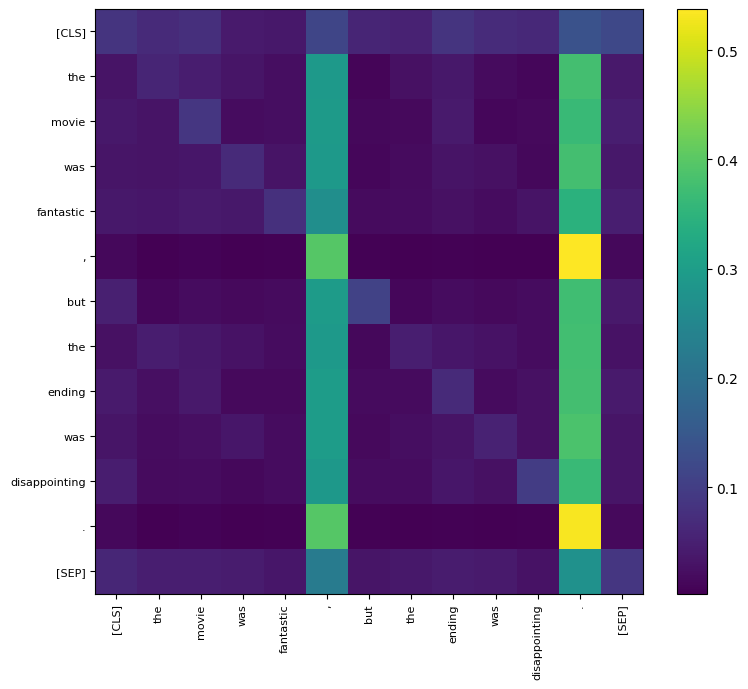

In [65]:
# Pre-trained
pre_attn, pre_tokens = get_last_layer_attention(pretrained_model, tok_pre, text, device)
plot_attention(pre_attn, pre_tokens, "Pre-trained BERT", head="mean")  # or head=0,1,2,...

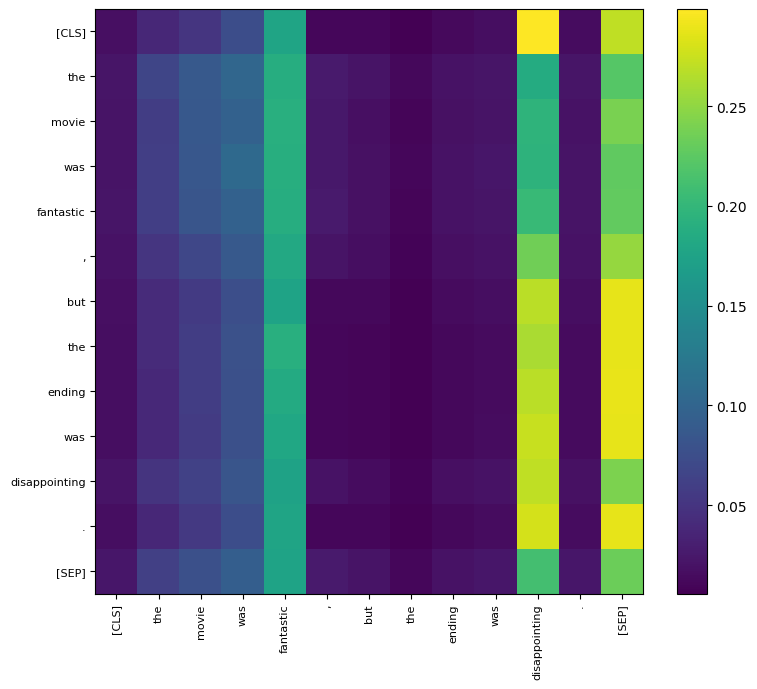

In [66]:
# Fine-tuned
ft_attn, ft_tokens = get_last_layer_attention(finetuned_model, tok_ft, text, device)
plot_attention(ft_attn, ft_tokens, "Fine-tuned BERT (IMDb)", head="mean")

### Ensuring the models are different

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model.to(device)
finetuned_model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [68]:
def compare_base_encoder(pretrained_model, finetuned_model):
    # compare a single tensor from the *BERT encoder* (not just classifier head)
    w_pre = pretrained_model.bert.encoder.layer[0].attention.self.query.weight.detach().cpu()
    w_ft  = finetuned_model.bert.encoder.layer[0].attention.self.query.weight.detach().cpu()
    diff = (w_pre - w_ft).abs().mean().item()
    print("Mean abs diff (encoder layer0 query.weight):", diff)

compare_base_encoder(pretrained_model, finetuned_model)

Mean abs diff (encoder layer0 query.weight): 0.0048670172691345215


In [69]:
# sanity check
# pick the device from the model (works even if you switch GPU/CPU later)
device = next(pretrained_model.parameters()).device

inputs = tokenizer(text, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

pretrained_model.eval()
finetuned_model.eval()

with torch.no_grad():
    pre_logits = pretrained_model(**inputs).logits
    ft_logits  = finetuned_model(**inputs).logits

print("pre logits:", pre_logits)
print("ft  logits:", ft_logits)
print("diff:", ft_logits - pre_logits)

pre logits: tensor([[0.1497, 0.1681]], device='cuda:0')
ft  logits: tensor([[ 2.1957, -2.2728]], device='cuda:0')
diff: tensor([[ 2.0460, -2.4408]], device='cuda:0')


In [70]:
tok_pre(text).input_ids

[101, 1996, 3185, 2001, 10392, 1010, 2021, 1996, 4566, 2001, 15640, 1012, 102]

In [71]:
tok_ft(text).input_ids

[101, 1996, 3185, 2001, 10392, 1010, 2021, 1996, 4566, 2001, 15640, 1012, 102]

In [72]:
print("Same object?", pretrained_model is finetuned_model)

Same object? False


In [73]:
def mean_abs_param_diff(m1, m2, prefix="bert.encoder.layer.0.attention.self.query.weight"):
    d1 = dict(m1.named_parameters())
    d2 = dict(m2.named_parameters())
    w1 = d1[prefix].detach().cpu()
    w2 = d2[prefix].detach().cpu()
    diff = (w1 - w2).abs().mean().item()
    maxd = (w1 - w2).abs().max().item()
    print(prefix)
    print("mean abs diff:", diff)
    print("max abs diff :", maxd)

mean_abs_param_diff(pretrained_model, finetuned_model, "bert.encoder.layer.0.attention.self.query.weight")
mean_abs_param_diff(pretrained_model, finetuned_model, "classifier.weight")
mean_abs_param_diff(pretrained_model, finetuned_model, "classifier.bias")

bert.encoder.layer.0.attention.self.query.weight
mean abs diff: 0.0048670172691345215
max abs diff : 0.03164132684469223
classifier.weight
mean abs diff: 0.022454969584941864
max abs diff : 0.10048433393239975
classifier.bias
mean abs diff: 0.0008999368292279541
max abs diff : 0.0008999404963105917


## **Task 3.5**

In [74]:
# taking sentences from the representative examples
positive_sentence = "Everything was just so perfect and excellent about this film"
negative_sentence = "One of the worst movies I've ever seen"
neutral_sentence = "It follows the tale of Sasha, The Sword Bearer, who is cursed with having a retractable sword in his forearm"

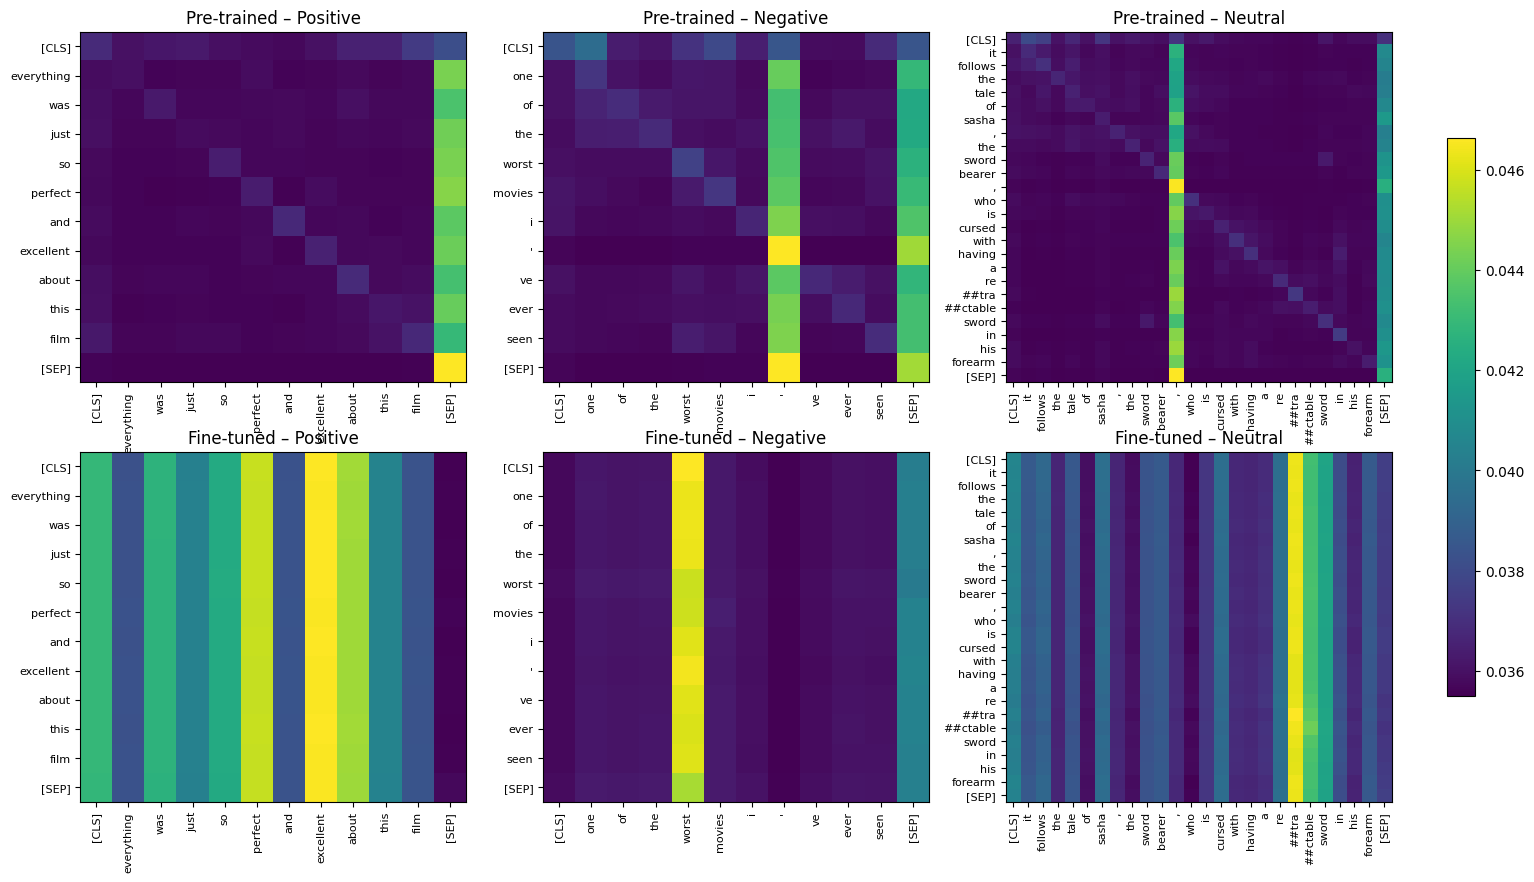

In [84]:
def _attn_to_numpy(attn_heads, head=None):
    # attn_heads: [H, T, T]
    if head is None:
        return attn_heads.mean(dim=0).detach().cpu().numpy()  # [T, T]
    return attn_heads[int(head)].detach().cpu().numpy()       # [T, T]
    
def plot_attention_grid_2x3(
    pretrained_model,
    finetuned_model,
    tok_pre,
    tok_ft,
    device,
    positive_sentence,
    negative_sentence,
    neutral_sentence,
    head="mean",
):
    sentences = [
        ("Positive", positive_sentence),
        ("Negative", negative_sentence),
        ("Neutral", neutral_sentence),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: Pre-trained model
    for col, (label, text) in enumerate(sentences):
        attn, tokens = get_last_layer_attention(pretrained_model, tok_pre, text, device)

        if head == "mean":
            attn_map = attn.mean(dim=0).cpu().numpy()
        else:
            attn_map = attn[int(head)].cpu().numpy()

        ax = axes[0, col]
        im = ax.imshow(attn_map, aspect="auto")
        ax.set_xticks(range(len(tokens)))
        ax.set_yticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=90, fontsize=8)
        ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f"Pre-trained – {label}")

    # Row 2: Fine-tuned model
    for col, (label, text) in enumerate(sentences):
        attn, tokens = get_last_layer_attention(finetuned_model, tok_ft, text, device)

        if head == "mean":
            attn_map = attn.mean(dim=0).cpu().numpy()
        else:
            attn_map = attn[int(head)].cpu().numpy()

        ax = axes[1, col]
        im = ax.imshow(attn_map, aspect="auto")
        ax.set_xticks(range(len(tokens)))
        ax.set_yticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=90, fontsize=8)
        ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f"Fine-tuned – {label}")

    # Shared colorbar
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

plot_attention_grid_2x3(
    pretrained_model,
    finetuned_model,
    tok_pre,
    tok_ft,
    device,
    positive_sentence,
    negative_sentence,
    neutral_sentence,
    head="mean"
)